# Data Augmentation with the Cifar-100 Classification

C:\ProgramData\miniforge3\envs\DL\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data (50000, 32, 32, 3)
Training label (50000, 1)
Max number of training label 99


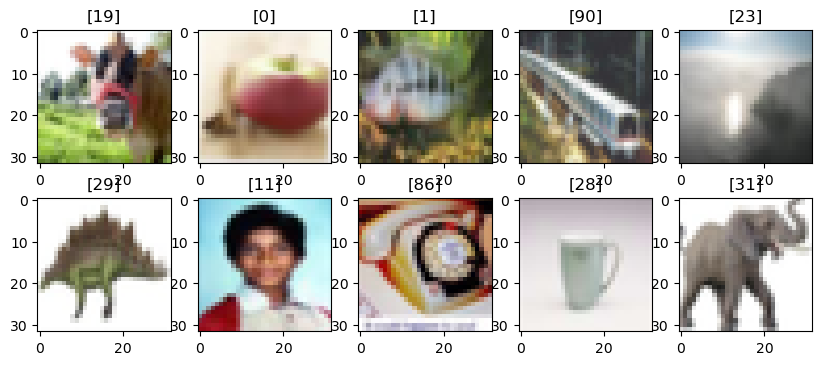

In [1]:
import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
print(f"Training data {x_train.shape}")
print(f"Training label {y_train.shape}")
print(f"Max number of training label {np.max(y_train)}")

import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for index, img in enumerate(x_train[0:10]):
    axs[index%2, int(index/2)].imshow(img, cmap="gray_r")
    axs[index%2, int(index/2)].set_title(y_train[index])


## Option 1: Create an augmentation network

In [2]:
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Conv2D, MaxPool2D, Flatten, BatchNormalization, Dropout
from keras.layers import RandomFlip, RandomRotation
from keras.regularizers import L2

# Picking some Layers from https://keras.io/api/layers/preprocessing_layers/image_augmentation/
augmentation = Sequential(name="augmentation")
augmentation.add(InputLayer((32, 32, 3)))
augmentation.add(RandomRotation(0.2))
augmentation.add(RandomFlip("horizontal"))
augmentation.summary()


Model: "augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation (RandomRotation)     │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 32, 32, 3)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
#does not work because augmentation layers are in passthrough mode during inference/predict
augmented_imgs = augmentation.predict(x_train[0:10]/255)
augmented_imgs.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


(10, 32, 32, 3)

In [6]:
# This will rotate the images, because the network is told that its training time
augmented_imgs = augmentation(x_train[0:10]/255 , training=True)
augmented_imgs.shape

TensorShape([10, 32, 32, 3])

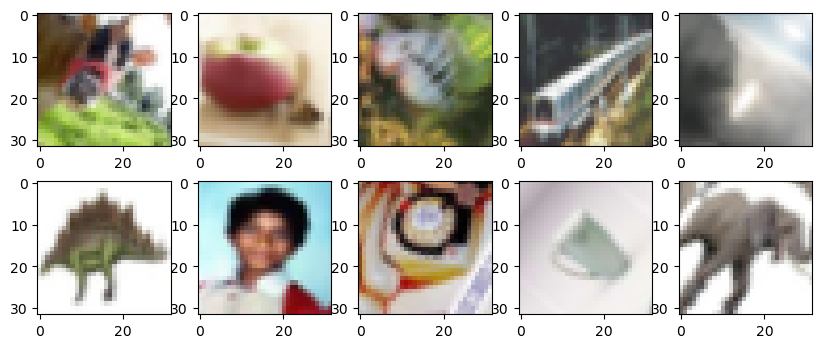

In [7]:
# Plot augmented pictures
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for index, img in enumerate(augmented_imgs):
    axs[index%2, int(index/2)].imshow(img, cmap="gray_r")


This augmentation network can be used inside another Sequencial network similar like a regular layer. Thus networks can be nested. 

In [8]:
nestedModel = Sequential()
nestedModel.add(InputLayer((32, 32, 3)))
nestedModel.add(augmentation);
#same as adding them directly. like here:
#nestedModel.add(RandomRotation(0.2))
#nestedModel.add(RandomFlip("horizontal"))
nestedModel.add(Flatten())
nestedModel.add(Dense(100, activation="sigmoid"))
nestedModel.add(Dense(100, activation="softmax"))
nestedModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)            │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         307,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          10,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 317,400 (1.21 MB)

 Trainable params: 317,400 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

## An overfitting Convnet

Results after 10 Epochs, 100 Iterations of 500 Samples:<br>
50/50 - 6s 112ms/step - <b>accuracy: 0.91</b> - <b>val_accuracy: 0.22</b>


In [9]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, BatchNormalization, Dropout
from keras.regularizers import L2

def createCNN():
    model = Sequential()
    model.add(BatchNormalization())
    model.add(Conv2D(20, kernel_size=(3, 3)))
    model.add(Conv2D(10, kernel_size=(3, 3), activation="relu"))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(150, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dense(100, activation="softmax"))

    model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [10]:
model = createCNN()
model.fit(
    x_train, # unaugmented data
    y_train, # original labels
    validation_data = (x_test, y_test),
    epochs=10, 
    batch_size=500)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.1619 - loss: 3.7024 - val_accuracy: 0.1314 - val_loss: 3.9836
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.2819 - loss: 3.0181 - val_accuracy: 0.2287 - val_loss: 3.3351
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.3605 - loss: 2.6193 - val_accuracy: 0.2618 - val_loss: 3.0972
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.4281 - loss: 2.3005 - val_accuracy: 0.2766 - val_loss: 3.0091
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 265ms/step - accuracy: 0.5012 - loss: 1.9953 - val_accuracy: 0.2591 - val_loss: 3.1113
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 252ms/step - accuracy: 0.5775 - loss: 1.6884 - val_accuracy: 0.2676 - val_loss: 3.1609
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.6530 - loss: 1.3968 - val_accuracy: 0.2610 - val_loss: 3.3082
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 257ms/step - accuracy: 0.7270 - loss: 1

## Now with Augmentation

Result without augmentation        
Epoch 10 Iteration 100 Batchsize 500<br>
loss: 0.3803 - <b>accuracy: 0.9400</b> - val_loss: 4.4131 - val_accuracy: <b>0.2145</b><br>
<br>
<br>
Result with augmentation<br>
Epoch 10 Iteration 100 BatchSize 500<br>
loss: 2.4029 - <b>accuracy: 0.3980</b> - val_loss: 2.7793 - val_accuracy: <b>0.3218</b><br>

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = Sequential([
    augmentation, 
    createCNN()])
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
model.fit(
    x_train, # unaugmented data
    y_train, # original labels
    validation_data = (x_test, y_test),
    epochs=10, 
    batch_size=500)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 356ms/step - accuracy: 0.1242 - loss: 3.8520 - val_accuracy: 0.1060 - val_loss: 3.9841
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - accuracy: 0.1865 - loss: 3.4465 - val_accuracy: 0.1779 - val_loss: 3.5248
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 305ms/step - accuracy: 0.2148 - loss: 3.2769 - val_accuracy: 0.2247 - val_loss: 3.2539
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 319ms/step - accuracy: 0.2386 - loss: 3.1532 - val_accuracy: 0.2425 - val_loss: 3.1446
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.2510 - loss: 3.0648 - val_accuracy: 0.2631 - val_loss: 3.0426
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 172ms/step - accuracy: 0.2662 - loss: 2.9855 - val_accuracy: 0.2599 - val_loss: 3.0145
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 241ms/step - accuracy: 0.2804 - loss: 2.9282 - val_accuracy: 0.2703 - val_loss: 2.9696
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 328ms/step - accuracy: 0.2891 - loss: 2